# Data Cleaning and Exploration

We will explore and clean the dataset. Duplicates and outliers will be considered and evaluated for exclusion. 

In [9]:
# Import the datasets and libraries
import pandas as pd

# Load the datasets
train_df = pd.read_csv("/Users/mateopozoruiz/Projects/Housing-Pricing-End-to-End-ML/data/raw/train_data.csv")
test_df = pd.read_csv("/Users/mateopozoruiz/Projects/Housing-Pricing-End-to-End-ML/data/raw/test_data.csv")
holdout_df = pd.read_csv("/Users/mateopozoruiz/Projects/Housing-Pricing-End-to-End-ML/data/raw/holdout_data.csv")

In [10]:
print(train_df.shape)
print(test_df.shape)
print(holdout_df.shape)

(585244, 39)
(149424, 39)
(149424, 39)


## Mapping cities to be encoded by latitude and longitude

Currently, cities are encoded by their name in the `city_full` column. We will map them to latitude and longitude coordinates by using the `usmetros` dataset. 

In [11]:
metros = pd.read_csv("/Users/mateopozoruiz/Projects/Housing-Pricing-End-to-End-ML/data/raw/raw_usmetros.csv")

In [12]:
train_df['city_full'].value_counts().head()

city_full
New York-Newark-Jersey City       78020
Chicago-Naperville-Elgin          35344
Los Angeles-Long Beach-Anaheim    33840
Philadelphia-Camden-Wilmington    31396
DC_Metro                          29516
Name: count, dtype: int64

In [13]:
# City mapping for non-matched cities
city_mapping = {
'Las Vegas-Henderson-Paradise': 'Las Vegas-Henderson-North Las Vegas, NV',
'Denver-Aurora-Lakewood': 'Denver-Aurora-Centennial, CO',
'Houston-The Woodlands-Sugar Land': 'Houston-Pasadena-The Woodlands, TX',
'Austin-Round Rock-Georgetown': 'Austin-Round Rock-San Marcos, TX',
'Miami-Fort Lauderdale-Pompano Beach': 'Miami-Fort Lauderdale-West Palm Beach, FL',
'San Francisco-Oakland-Berkeley': 'San Francisco-Oakland-Fremont, CA',
'DC_Metro': 'Washington-Arlington-Alexandria, DC-VA-MD-WV',
'Atlanta-Sandy Springs-Alpharetta': 'Atlanta-Sandy Springs-Roswell, GA',
'Pittsburgh': 'Pittsburgh, PA',
'Boston-Cambridge-Newton': 'Boston-Cambridge-Newton, MA-NH',
'Tampa-St. Petersburg-Clearwater': 'Tampa-St. Petersburg-Clearwater, FL',
'Baltimore-Columbia-Towson': 'Baltimore-Columbia-Towson, MD',
'Portland-Vancouver-Hillsboro': 'Portland-Vancouver-Hillsboro, OR-WA',
'Philadelphia-Camden-Wilmington': 'Philadelphia-Camden-Wilmington, PA-NJ-DE-MD', 
'New York-Newark-Jersey City': 'New York-Newark-Jersey City, NY-NJ', 
'Chicago-Naperville-Elgin': 'Chicago-Naperville-Elgin, IL-IN',
'Orlando-Kissimmee-Sanford': 'Orlando-Kissimmee-Sanford, FL',
'Seattle-Tacoma-Bellevue': 'Seattle-Tacoma-Bellevue, WA',
'San Diego-Chula Vista-Carlsbad': 'San Diego-Chula Vista-Carlsbad, CA',
'St. Louis': 'St. Louis, MO-IL',
'Sacramento-Roseville-Folsom': 'Sacramento-Roseville-Folsom, CA', 
'Phoenix-Mesa-Chandler': 'Phoenix-Mesa-Chandler, AZ', 
'Riverside-San Bernardino-Ontario': 'Riverside-San Bernardino-Ontario, CA',
'San Antonio-New Braunfels': 'San Antonio-New Braunfels, TX',
'Detroit-Warren-Dearborn': 'Detroit-Warren-Dearborn, MI',
'Cincinnati': 'Cincinnati, OH-KY-IN',
'Charlotte-Concord-Gastonia': 'Charlotte-Concord-Gastonia, NC-SC',
'Los Angeles-Long Beach-Anaheim': 'Los Angeles-Long Beach-Anaheim, CA',
'Dallas-Fort Worth-Arlington': 'Dallas-Fort Worth-Arlington, TX',
'Minneapolis-St. Paul-Bloomington': 'Minneapolis-St. Paul-Bloomington, MN-WI'
}

In [14]:
def clean_and_merge(df: pd.DataFrame) -> pd.DataFrame:
    """
    Cleans the input DataFrame and merges it with the metros DataFrame.
    """
    df['city_full'] = df['city_full'].replace(city_mapping)
    
    df = df.merge(
        metros[["metro_full", "lat", "lng"]], 
        how="left", 
        left_on="city_full", 
        right_on="metro_full"
    )
    df.drop(columns=["metro_full"], inplace=True)

    # Check if any city is not matched
    unmatched_cities = df[df['lat'].isnull()]['city_full'].unique()
    if len(unmatched_cities) > 0:
        print("Unmatched cities:", unmatched_cities)
    else:
        print("All cities matched successfully.")

    return df

In [15]:
# Apply the cleaning and merging function to both datasets
train_df = clean_and_merge(train_df)
test_df = clean_and_merge(test_df)
holdout_df = clean_and_merge(holdout_df)

All cities matched successfully.
All cities matched successfully.
All cities matched successfully.


In [16]:
print(train_df.shape)
print(test_df.shape)
print(holdout_df.shape)

(585244, 41)
(149424, 41)
(149424, 41)


In [17]:
train_df.head()

,date,median_sale_price,median_list_price,median_ppsf,median_list_ppsf,homes_sold,pending_sales,new_listings,inventory,median_dom,...,Median Home Value,Total Labor Force,Unemployed Population,Total School Age Population,Total School Enrollment,Median Commute Time,price,city_full,lat,lng
0,2012-03-31,46550.0,217450.0,31.813674,110.183666,14.0,23.0,44.0,64.0,59.5,...,279500.0,3171.0,460.0,5408.0,5408.0,2492.0,200773.999557,"Atlanta-Sandy Springs-Roswell, GA",33.7338,-84.3922
1,2012-03-31,200000.0,7500.0,104.931794,79.265873,1.0,1.0,1.0,2.0,290.0,...,94600.0,1171.0,52.0,2376.0,2376.0,1018.0,105863.681174,"Pittsburgh, PA",40.4744,-79.8632
2,2012-03-31,75750.0,92400.0,165.898618,63.412698,2.0,2.0,4.0,13.0,193.0,...,62800.0,894.0,30.0,2106.0,2106.0,807.0,60152.096646,"Pittsburgh, PA",40.4744,-79.8632
3,2012-03-31,79900.0,79900.0,0.696203,0.000000,1.0,1.0,1.0,1.0,46.0,...,66200.0,216.0,7.0,414.0,414.0,208.0,44042.242632,"Pittsburgh, PA",40.4744,-79.8632
4,2012-03-31,196000.0,198000.0,122.807018,124.060150,1.0,1.0,1.0,1.0,49.0,...,79300.0,711.0,61.0,1489.0,1489.0,641.0,126572.277873,"Pittsburgh, PA",40.4744,-79.8632


## Cleaning Duplicates

In [18]:
# Original train shape
print("Original train shape:", train_df.shape)

duplicated_rows = train_df[train_df.duplicated()].shape[0]
print("Number of duplicated rows in train set:", duplicated_rows)

# Duplicated rows excluding the date column
duplicated_rows_date_excluded = train_df[train_df.duplicated(subset=train_df.columns.difference(['date', 'year']))].shape[0]
print("Number of duplicated rows in train set (excluding date and year):", duplicated_rows_date_excluded)


Original train shape: (585244, 41)
Number of duplicated rows in train set: 0
Number of duplicated rows in train set (excluding date and year): 6321


In [19]:
# Original test shape
print("Original test shape:", test_df.shape)

duplicated_rows = test_df[test_df.duplicated()].shape[0]
print("Number of duplicated rows in test set:", duplicated_rows)

# Duplicated rows excluding the date column
duplicated_rows_date_excluded = test_df[test_df.duplicated(subset=test_df.columns.difference(['date', 'year']))].shape[0]
print("Number of duplicated rows in test set (excluding date and year):", duplicated_rows_date_excluded)

Original test shape: (149424, 41)
Number of duplicated rows in test set: 0
Number of duplicated rows in test set (excluding date and year): 726


In [20]:
# Original holdout shape
print("Original holdout shape:", holdout_df.shape)

duplicated_rows = holdout_df[holdout_df.duplicated()].shape[0]
print("Number of duplicated rows in holdout set:", duplicated_rows)

# Duplicated rows excluding the date column
duplicated_rows_date_excluded = holdout_df[holdout_df.duplicated(subset=holdout_df.columns.difference(['date', 'year']))].shape[0]
print("Number of duplicated rows in holdout set (excluding date and year):", duplicated_rows_date_excluded)

Original holdout shape: (149424, 41)
Number of duplicated rows in holdout set: 0
Number of duplicated rows in holdout set (excluding date and year): 343


We dont want to keep rows where all is the same, just a few weeks/months apart. So we will drop those rows.

In [21]:
# Delete duplicated rows from train set 
train_df = train_df.drop_duplicates(subset=train_df.columns.difference(['date', 'year']), keep=False)

print("New train shape after removing duplicates:", train_df.shape)

New train shape after removing duplicates: (576860, 41)


In [22]:
# Delete duplicated rows from test set
test_df = test_df.drop_duplicates(subset=test_df.columns.difference(['date', 'year']), keep=False)

print("New test shape after removing duplicates:", test_df.shape)

New test shape after removing duplicates: (148449, 41)


In [23]:
# Delete duplicated rows from holdout set
holdout_df = holdout_df.drop_duplicates(subset=holdout_df.columns.difference(['date', 'year']), keep=False)

print("New holdout shape after removing duplicates:", holdout_df.shape)

New holdout shape after removing duplicates: (148945, 41)


## Clean Outliers

In [24]:
train_df["median_list_price"].describe()

count    5.768600e+05
mean     3.734342e+05
std      2.318935e+06
min      0.000000e+00
25%      1.724500e+05
50%      2.760000e+05
75%      4.390000e+05
max      1.000000e+09
Name: median_list_price, dtype: float64

Matplotlib is building the font cache; this may take a moment.


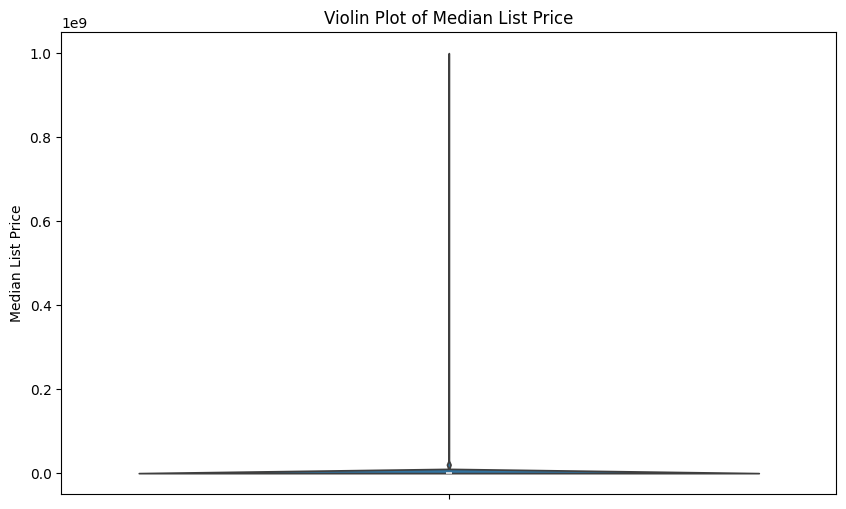

In [25]:
# Plot the data as a violin plot
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
sns.violinplot(y=train_df["median_list_price"])
plt.title("Violin Plot of Median List Price")
plt.ylabel("Median List Price")
plt.show()

In [26]:
# Get the top 1% data 
top_1_percent = train_df.nlargest(int(0.01 * len(train_df)), 'median_list_price')
print(top_1_percent.shape)
top_1_percent.head()

(5768, 41)


,date,median_sale_price,median_list_price,median_ppsf,median_list_ppsf,homes_sold,pending_sales,new_listings,inventory,median_dom,...,Median Home Value,Total Labor Force,Unemployed Population,Total School Age Population,Total School Enrollment,Median Commute Time,price,city_full,lat,lng
271684,2015-10-31,439000.0,999999999.0,218.867925,236.391156,243.0,269.0,671.0,259.0,46.0,...,535500.0,36595.0,1960.0,61237.0,61237.0,32125.0,514388.985999,"Washington-Arlington-Alexandria, DC-VA-MD-WV",38.8446,-77.5092
275824,2015-11-30,425000.0,999999999.0,220.055710,236.634569,241.0,284.0,616.0,196.0,47.0,...,535500.0,36595.0,1960.0,61237.0,61237.0,32125.0,514884.401131,"Washington-Arlington-Alexandria, DC-VA-MD-WV",38.8446,-77.5092
283729,2015-12-31,439444.0,999999999.0,217.479377,231.798505,254.0,255.0,536.0,136.0,53.0,...,535500.0,36595.0,1960.0,61237.0,61237.0,32125.0,515206.049773,"Washington-Arlington-Alexandria, DC-VA-MD-WV",38.8446,-77.5092
312332,2016-05-31,270000.0,50449949.5,232.758621,4156.568441,1.0,1.0,2.0,2.0,264.0,...,607100.0,135.0,0.0,239.0,239.0,122.0,673997.281067,"Washington-Arlington-Alexandria, DC-VA-MD-WV",38.8446,-77.5092
323492,2016-06-30,415000.0,50449949.5,257.508343,4156.568441,2.0,2.0,2.0,2.0,324.5,...,607100.0,135.0,0.0,239.0,239.0,122.0,673997.281067,"Washington-Arlington-Alexandria, DC-VA-MD-WV",38.8446,-77.5092


In [27]:
# Print the value counts of the top 1% data
print(top_1_percent["median_list_price"].value_counts().sort_index(ascending=False))

median_list_price
999999999.0     3
50449949.5      3
27800000.0      1
19990000.0     38
15849000.0      1
               ..
1744500.0       1
1744000.0       1
1743500.0       1
1742000.0       1
1740000.0       3
Name: count, Length: 1597, dtype: int64


We will drop outliers above 19M, in order to keep the data well distributed. 

In [28]:
# Clean outliers above 19M for train, test, and holdout set
train_df = train_df[train_df["median_list_price"] <= 19000000].copy()
test_df = test_df[test_df["median_list_price"] <= 19000000].copy()
holdout_df = holdout_df[holdout_df["median_list_price"] <= 19000000].copy()

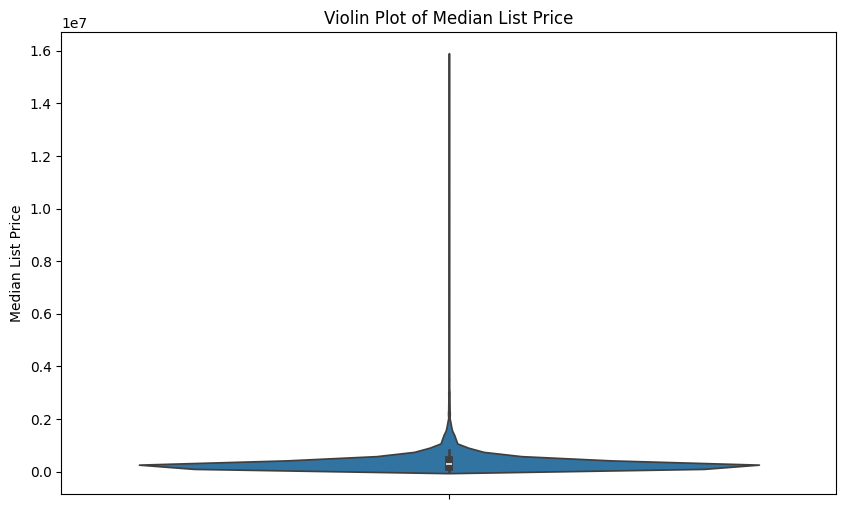

In [29]:
# Plot the data as a violin plot
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
sns.violinplot(y=train_df["median_list_price"])
plt.title("Violin Plot of Median List Price")
plt.ylabel("Median List Price")
plt.show()

In [31]:
# Save the cleaned datasets
train_df.to_csv("/Users/mateopozoruiz/Projects/Housing-Pricing-End-to-End-ML/data/processed/cleaning_train_data.csv", index=False)
test_df.to_csv("/Users/mateopozoruiz/Projects/Housing-Pricing-End-to-End-ML/data/processed/cleaning_test_data.csv", index=False)
holdout_df.to_csv("/Users/mateopozoruiz/Projects/Housing-Pricing-End-to-End-ML/data/processed/cleaning_holdout_data.csv", index=False)

## Housing Prices Exploration

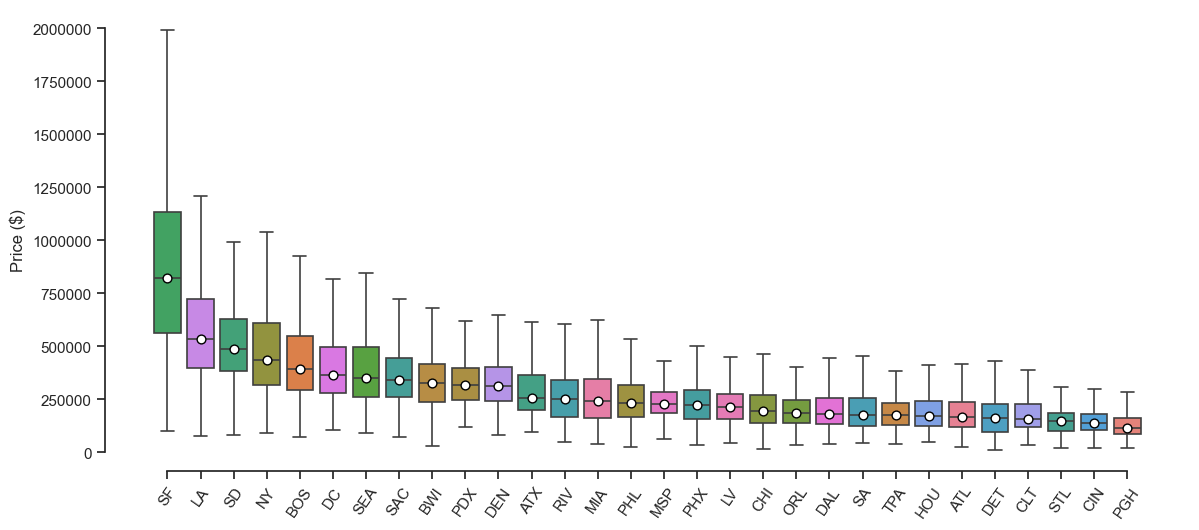

In [32]:
import colorsys

sns.set_theme(style="whitegrid")

# Boxplot for housing prices across cities ordered by median price

top_cities = train_df["city"].value_counts().head(30).index.tolist()
df_city = train_df[train_df["city"].isin(top_cities)]
city_order = (
    df_city.groupby("city")["price"]
        .median()
        .sort_values(ascending=False)
        .index
)

base = sns.color_palette("rocket_r", len(city_order))

sns.set_theme(style="ticks")
fig, ax = plt.subplots(figsize=(14, 6))

sns.boxplot(
x="city", y="price", data=df_city,
order=city_order,
showfliers=False, linewidth=1.2, ax=ax, hue="city", legend=False
)

medians = df_city.groupby("city")["price"].median().loc[city_order]

for tick, median in enumerate(medians):
    ax.scatter(tick, median, color="white", edgecolor="black", zorder=5, s=40)

ax.set_xlabel("")
ax.set_ylabel("Price ($)")
ax.tick_params(axis="x", rotation=55)
sns.despine(trim=True)
ax.grid(False)
ax.ticklabel_format(axis="y", style="plain")

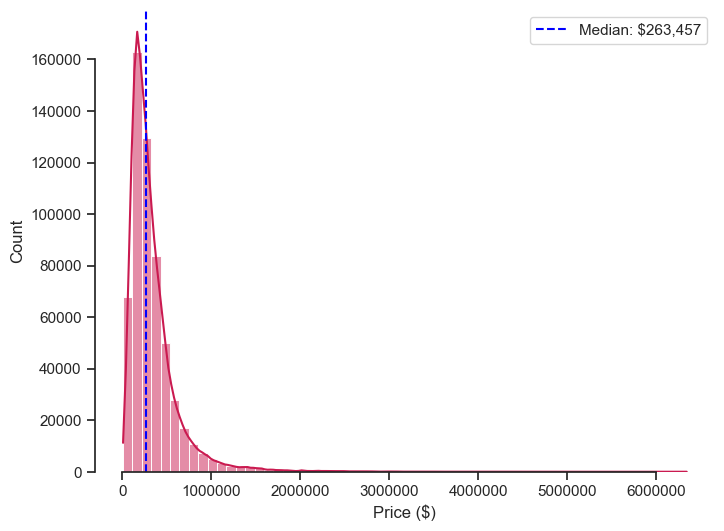

In [33]:
# Distribution of housing prices across the dataset

sns.set_theme(style="ticks")
fig, ax = plt.subplots(figsize=(8, 6))

sns.histplot(train_df["price"].dropna(), bins=60, kde=True, color=sns.color_palette("rocket_r", 1)[0], ax=ax)
median_price = train_df["price"].median()
ax.axvline(median_price, color="blue", linestyle="--", label=f"Median: ${median_price:,.0f}")
ax.set_xlabel("Price ($)")
ax.set_ylabel("Count")
ax.legend()
sns.despine(trim=True)
ax.grid(False)
ax.ticklabel_format(axis="x", style="plain")

plt.show()